# Discretization
Data discretization is a preprocessing technique used to transform continuous or numerical data into discrete categories or bins. This process can be particularly useful for machine learning algorithms that handle categorical data more effectively than continuous data. It can also help to improve model interpretability and handle outliers more robustly.

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer


In [27]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
df['age'].fillna(df['age'].median(),inplace=True)
df['fare'].fillna(df['fare'].median(),inplace=True)

In [29]:
import warnings
warnings.filterwarnings('ignore')

<Axes: xlabel='age', ylabel='Count'>

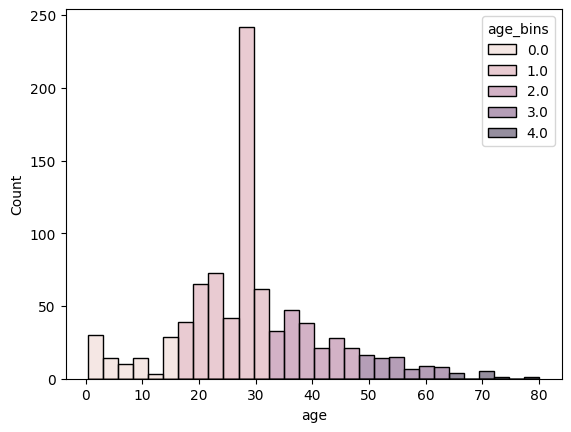

In [33]:
# age discretizer
age_discretizer = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='uniform')
df['age_bins']=age_discretizer.fit_transform(df[['age']])
sns.histplot(df,x='age',hue='age_bins')

<Axes: xlabel='age', ylabel='Count'>

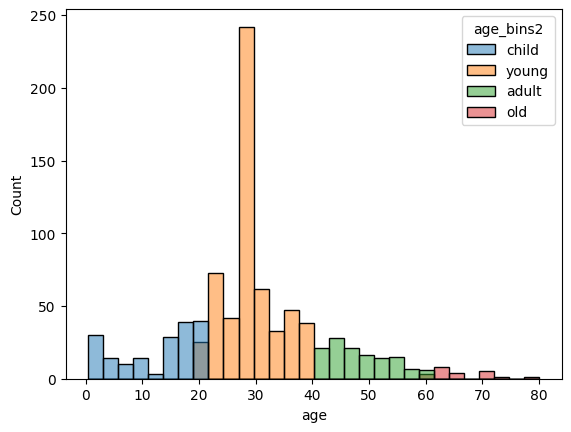

In [35]:
# pandas manual binning
bins=[0,20,40,60,80]
labels=['child','young','adult','old']
df['age_bins2'] = pd.cut(df['age'],bins=bins,labels = labels)
sns.histplot(df,x='age',hue='age_bins2')